In [1]:
from tradepy.data.loader import load_future
from tradepy.config.config import load_config, load_symbols, load_feature_config, load_exclude_config
from tradepy.data.cleaner import add_trading_date_by_gap
from tradepy.data.resampler import resample_ohlcv, daily_ohlcv_cummulative
from tradepy.features.generate import generate_features
from tradepy.features.quality_check import data_quality_report
from tradepy.supervised.load import prepare_all
from tradepy.paths import EXCLUDE_CONFIG, SYSTEM_CONFIG
from tradepy.supervised.target import target_triple_barrier_interday
from tradepy.supervised.pretrain import filter_features
from tradepy.supervised.models import GoldLSTM_L1_Move, GoldLSTM_L2_Dir, GoldGRU_L1_Move, GoldGRU_L2_Dir, BasicLSTM_L1_Move, BasicLSTM_L2_Dir, BasicGRU_L1_Move, BasicGRU_L2_Dir
from tradepy.supervised.train import train_walk_forward_2level, grid_search_thresholds
from tradepy.supervised.posttrain import evaluate_model_classification, tune_threshold_wf, save_trading_model_2level
from tradepy.paths import MODELS_DIR

In [2]:
symbols = load_symbols()
cfg = load_config()

In [3]:
symbols


['AD',
 'BP',
 'CL',
 'EC',
 'ES',
 'GC',
 'MFXI',
 'NG',
 'NQ',
 'YM',
 'ZB',
 'ZN',
 'ZS']

In [4]:
ASSET = symbols[5]
MINUTES             = cfg['sampling_minutes']        # 240
RETURN_HORIZON_MIN  = cfg['return_horizon_min']      # 2880

In [5]:
df_final, spec = prepare_all(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Data/features_config.json")


In [6]:
exclude = load_exclude_config(MINUTES)


In [7]:
feature_cols_triple = [c for c in df_final.columns if c not in exclude['exclude_cols_triple']]


In [8]:
df_final_triple_real = target_triple_barrier_interday(df_final, spec, return_horizon_days=int(RETURN_HORIZON_MIN/60/24), profit_factor=1.8, tp_atr_mult=1.4, sl_atr_mult=1.2)
df_final_triple_real["target_class"] = df_final_triple_real[f"target_tb_{int(RETURN_HORIZON_MIN/60/24)}d"]

In [9]:
features_finales_test, params = filter_features(df_final_triple_real, feature_cols_triple, 'target_class')


Eliminando 55 features redundantes por correlación
Configuración sugerida:
{'lookback': 30, 'train_size': 6000, 'test_size': 180, 'gap': 12, '_candles_per_day': 6, '_horizon_bars': 12}
Features seleccionadas (62):
['volume_cum' 'signal' 'histogram' 'adx' 'rsi' 'slowk' 'cmo' 'williams_r'
 'cci' 'roc_10' 'roc_5' 'hv' 'obv' 'obv_norm' 'obv_roc_5' 'obv_roc_10'
 'obv_z' 'obv_rel' 'obv_delta' 'ad_roc_5' 'ad_roc_10' 'ad_z'
 'volume_range' 'volume_price' 'mfi' 'cmf' 'efi' 'vwap' 'avg_volume'
 'relative_volume' 'volume_delta' 'pct_above_ma_20' 'pct_above_ma_50'
 'slope_10' 'dist_low_cum_ticks' 'dist_open_day_ticks'
 'vol_weight_intraday' 'hour' 'hour_sin' 'is_ny' 'return_horizon_2880m'
 'return_lag_1' 'return_lag_5' 'return_lag_10' 'return_lag_20'
 'return_std_5' 'return_std_10' 'rolling_skew_10' 'rolling_kurt_10'
 'rolling_skew_20' 'rolling_kurt_20' 'dist_to_last_swing_high'
 'dist_to_last_swing_low' 'swing_range' 'swing_range_pct'
 'close_in_swing_range' 'atr_norm' 'atr_z' 'vol_vol_ratio'
 'd

In [10]:
import torch
from tqdm import tqdm
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import torch.nn as nn
from tradepy.supervised.train import create_lstm_dataset

def train_walk_forward_2level_v2(
    df,
    feature_cols,
    target_col,           # Columna original: 0=SELL, 1=HOLD, 2=BUY
    model_class_l1,       # GoldLSTM_L1_Move_v2
    model_class_l2,       # GoldLSTM_L2_Dir_v2
    train_size=40000,
    test_size=10000,
    gap=2,
    lookback=24,
    epochs=15,
    batch_size=256,
    lr=5e-4,
    threshold_move=0.5,
    threshold_dir=0.5
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    all_results = []

    # Asegurar orden temporal estricto antes de segmentar en ventanas
    df = df.sort_values('datetime').reset_index(drop=True)
    df_copy = df.copy()
    
    # targets derivados
    df_copy['_target_l1'] = (df_copy[target_col] != 1).astype(int)   # 0=HOLD, 1=ACCION
    df_copy['_target_l2'] = (df_copy[target_col] == 2).astype(int)   # 0=SELL, 1=BUY

    # Generar datasets globales
    X_all, y_l1_all = create_lstm_dataset(df_copy, feature_cols, '_target_l1', lookback)
    _,     y_l2_all = create_lstm_dataset(df_copy, feature_cols, '_target_l2', lookback)
    dt_all = df_copy['datetime'].values[lookback:]

    total_samples = len(X_all)

    for start in tqdm(range(0, total_samples - train_size - test_size - gap, test_size), desc="WF 2-Level V2"):

        train_end   = start + train_size
        test_start  = train_end + gap
        test_end    = test_start + test_size

        # --- SPLIT ---
        X_train = X_all[start:train_end]
        X_test  = X_all[test_start:test_end]
        y_l1_train = y_l1_all[start:train_end]
        y_l1_test  = y_l1_all[test_start:test_end]
        y_l2_train = y_l2_all[start:train_end]
        y_l2_test  = y_l2_all[test_start:test_end]
        dt_test    = dt_all[test_start:test_end]

        # --- ESCALADO SEGURO (Evita Data Leakage temporal) ---
        sc = RobustScaler()
        N_train, L, F = X_train.shape
        
        # Ajustamos el escalador colapsando solo las muestras de entrenamiento sin alterar los pasos de tiempo de forma cruzada
        X_train_2d = X_train.reshape(-1, F)
        sc.fit(X_train_2d)
        
        # Transformamos manteniendo las dimensiones limpias
        X_train_scaled = sc.transform(X_train_2d).reshape(N_train, L, F)
        
        N_test = X_test.shape[0]
        X_test_scaled  = sc.transform(X_test.reshape(-1, F)).reshape(N_test, L, F)

        # --- TENSORES ---
        X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
        X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32).to(device)

        # =====================================================
        # NIVEL 1 — ¿Hay movimiento? (0=HOLD, 1=ACCION)
        # =====================================================
        y_l1_train_t = torch.tensor(y_l1_train, dtype=torch.long).to(device)

        # Corregimos cálculo de pesos inversos proporcionales estables
        counts_l1 = np.bincount(y_l1_train.astype(int), minlength=2)
        w_l1 = len(y_l1_train) / (2.0 * counts_l1 + 1e-6)
        w_l1[1] *= 2.5   # Penalización extra agresiva por fallar una señal operativa (BUY/SELL)
        w_l1 = w_l1 / w_l1.sum()
        w_l1_t = torch.tensor(w_l1, dtype=torch.float32).to(device)

        model_l1 = model_class_l1(input_dim=len(feature_cols), output_dim=2).to(device)
        opt_l1   = torch.optim.AdamW(model_l1.parameters(), lr=lr, weight_decay=1e-4) # AdamW es mejor para regularizar la atención
        crit_l1  = nn.CrossEntropyLoss(weight=w_l1_t)
        
        # DataLoader con drop_last=True para estabilizar OneCycleLR de forma matemática exacta
        loader_l1 = DataLoader(TensorDataset(X_train_t, y_l1_train_t), batch_size=batch_size, shuffle=True, drop_last=True)
        
        sched_l1 = torch.optim.lr_scheduler.OneCycleLR(
            opt_l1, max_lr=lr,
            steps_per_epoch=len(loader_l1),
            epochs=epochs, pct_start=0.3
        )
        
        scaler_amp = torch.amp.GradScaler(enabled=(device.type == "cuda"))

        model_l1.train()
        for epoch in range(epochs):
            for bx, by in loader_l1:
                opt_l1.zero_grad()
                with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                    loss = crit_l1(model_l1(bx), by)
                scaler_amp.scale(loss).backward()
                scaler_amp.unscale_(opt_l1)
                nn.utils.clip_grad_norm_(model_l1.parameters(), 1.0)
                scaler_amp.step(opt_l1)
                scaler_amp.update()
                sched_l1.step()

        # =====================================================
        # NIVEL 2 — ¿BUY o SELL? (Filas filtradas con movimiento)
        # =====================================================
        mask_move = (y_l1_train == 1)
        X_l2_train = X_train_scaled[mask_move]
        y_l2_train_filt = y_l2_train[mask_move]

        # Validar que existan suficientes datos operativos en esta ventana de tiempo
        if len(y_l2_train_filt) > batch_size:
            y_l2_train_t = torch.tensor(y_l2_train_filt, dtype=torch.long).to(device)
            X_l2_train_t = torch.tensor(X_l2_train, dtype=torch.float32).to(device)

            counts_l2 = np.bincount(y_l2_train_filt.astype(int), minlength=2)
            w_l2 = len(y_l2_train_filt) / (2.0 * counts_l2 + 1e-6)
            w_l2 = w_l2 / w_l2.sum()
            w_l2_t = torch.tensor(w_l2, dtype=torch.float32).to(device)

            model_l2 = model_class_l2(input_dim=len(feature_cols), output_dim=2).to(device)
            opt_l2   = torch.optim.AdamW(model_l2.parameters(), lr=lr, weight_decay=1e-4)
            crit_l2  = nn.CrossEntropyLoss(weight=w_l2_t)
            
            loader_l2 = DataLoader(TensorDataset(X_l2_train_t, y_l2_train_t), batch_size=batch_size, shuffle=True, drop_last=True)
            
            sched_l2 = torch.optim.lr_scheduler.OneCycleLR(
                opt_l2, max_lr=lr,
                steps_per_epoch=len(loader_l2),
                epochs=epochs, pct_start=0.3
            )

            model_l2.train()
            for epoch in range(epochs):
                for bx, by in loader_l2:
                    opt_l2.zero_grad()
                    with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                        loss = crit_l2(model_l2(bx), by)
                    scaler_amp.scale(loss).backward()
                    scaler_amp.unscale_(opt_l2)
                    nn.utils.clip_grad_norm_(model_l2.parameters(), 1.0)
                    scaler_amp.step(opt_l2)
                    scaler_amp.update()
                    sched_l2.step()
        else:
            print(f"⚠️ Advertencia: Muestras insuficientes para entrenar L2 en la ventana {start}. Se omite actualización.")

        # =====================================================
        # INFERENCIA EN CASCADA
        # =====================================================
        model_l1.eval()
        model_l2.eval()

        with torch.no_grad():
            probs_l1 = torch.softmax(model_l1(X_test_t), dim=1).cpu().numpy()
            probs_l2 = torch.softmax(model_l2(X_test_t), dim=1).cpu().numpy()

        preds = np.ones(len(probs_l1), dtype=int)   # Default: HOLD (1)

        for i in range(len(probs_l1)):
            # L1: ¿Supera la probabilidad exigida para salir de HOLD?
            if probs_l1[i, 1] > threshold_move:
                if threshold_dir is None:
                    # Si no hay umbral en dirección, elegimos la mayor probabilidad entre SELL (0) y BUY (2)
                    preds[i] = 2 if probs_l2[i, 1] > probs_l2[i, 0] else 0
                else:
                    # Exigimos confianza estricta en la dirección
                    if probs_l2[i, 1] > threshold_dir:
                        preds[i] = 2  # BUY
                    elif probs_l2[i, 0] > threshold_dir:
                        preds[i] = 0  # SELL

        # --- RECOLECCIÓN DE RESULTADOS ---
        original_test = df_copy[target_col].values[lookback:][test_start:test_end]
        
        step_res = pd.DataFrame({
            'datetime':   dt_test,
            'actual':     original_test, 
            'pred':       preds,
            'prob_move':  probs_l1[:, 1],
            'prob_sell':  probs_l2[:, 0],
            'prob_buy':   probs_l2[:, 1],
        })

        all_results.append(step_res)

        # Liberación de memoria limpia en GPU
        del X_train_t, X_test_t
        torch.cuda.empty_cache()

    return pd.concat(all_results, ignore_index=True), all_results, model_l1, model_l2, sc

In [11]:
class BahdanauAttention(nn.Module):
    """Mecanismo de atención con vector de contexto aprendible para series temporales."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.V = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_out):
        # lstm_out shape: (batch_size, seq_len, hidden_dim)
        
        # Puntuación de atención (Score)
        score = torch.tanh(self.W(lstm_out)) # (batch_size, seq_len, hidden_dim)
        attention_weights = torch.softmax(self.V(score), dim=1) # (batch_size, seq_len, 1)
        
        # Context vector (Suma ponderada a lo largo del tiempo)
        context = (attention_weights * lstm_out).sum(dim=1) # (batch_size, hidden_dim)
        return context, attention_weights


class GoldLSTM_L1_Move_v2(nn.Module):
    """Nivel 1 Avanzado (v2): ¿Hay movimiento? → 0=HOLD, 1=ACCIÓN"""
    def __init__(self, input_dim, output_dim=2, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Atención real sustituyendo a la proyección lineal simple
        self.attention = BahdanauAttention(hidden_dim)
        
        # LayerNorm es mucho más estable para series temporales financieras que BatchNorm
        self.norm = nn.LayerNorm(hidden_dim)
        
        # MLP clasificador con regularización agresiva para evitar memorizar ruido
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.LayerNorm(64), # Reemplaza a BatchNorm1d
            nn.GELU(),
            nn.Dropout(0.4),  # Incrementado a 0.4 para mitigar el sobreajuste
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Dropout(0.3),  # Incrementado a 0.3
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        lstm_out, (h_n, _) = self.lstm(x)
        
        # 1. Extraemos el vector de contexto mediante atención ponderada temporal
        context, attn_w = self.attention(lstm_out)
        
        # 2. Combinamos el contexto de atención con el último estado oculto (h_n[-1])
        # Esto asegura que el modelo no olvide la información más reciente de la secuencia
        x_features = context + h_n[-1] 
        
        # 3. Normalización y clasificación
        x_features = self.norm(x_features)
        return self.head(x_features)


class GoldLSTM_L2_Dir_v2(nn.Module):
    """Nivel 2 Avanzado (v2): ¿Qué dirección? → 0=SELL, 1=BUY"""
    def __init__(self, input_dim, output_dim=2, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.attention = BahdanauAttention(hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        lstm_out, (h_n, _) = self.lstm(x)
        
        context, attn_w = self.attention(lstm_out)
        
        # Conexión residual con el último estado oculto
        x_features = context + h_n[-1]
        
        x_features = self.norm(x_features)
        return self.head(x_features)

In [12]:
results, results_by_fold, model_l1, model_l2, sc = train_walk_forward_2level_v2(
    df_final_triple_real,
    features_finales_test,
    'target_class',
    model_class_l1=GoldLSTM_L1_Move_v2,
    model_class_l2=GoldLSTM_L2_Dir_v2,
    train_size=params["train_size"],
    test_size=params["test_size"],
    gap=params["gap"],
    lookback=params["lookback"],
    epochs=15,
    batch_size=256,
    lr=5e-4,
    threshold_move=0.55,
    threshold_dir=0.52
)

WF 2-Level V2:   0%|          | 0/134 [00:00<?, ?it/s]C:\Users\LIJUN\AppData\Local\Temp\ipykernel_20284\3424731141.py:115: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_l1.step()
C:\Users\LIJUN\AppData\Local\Temp\ipykernel_20284\3424731141.py:157: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_l2

📊 --- CLASIFICACIÓN POR CLASE ---
              precision    recall  f1-score   support

    SELL (0)       0.30      0.22      0.25      4816
    HOLD (1)       0.64      0.74      0.69     14783
     BUY (2)       0.31      0.25      0.28      4521

    accuracy                           0.54     24120
   macro avg       0.42      0.40      0.41     24120
weighted avg       0.51      0.54      0.52     24120



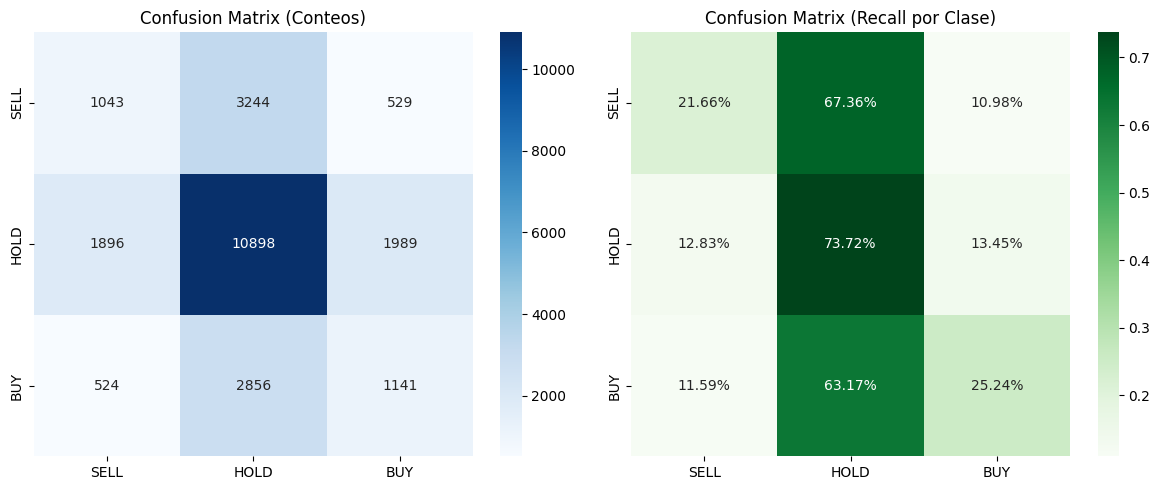


⭐ Métricas Globales:
Accuracy: 0.5424
F1-Score (Macro): 0.4056  <-- Si es < 0.33, el modelo es puro azar


{'accuracy': 0.5423714759535655, 'f1_macro': 0.40558482447266453}

In [13]:
evaluate_model_classification(results)

In [14]:
best_params, df_grid = grid_search_thresholds(results, move_thresholds=[0.40, 0.45, 0.48, 0.50, 0.52], metric='f1_macro')


Métrica: f1_macro
Mejor score: 0.4035 con {'threshold_move': 0.52, 'threshold_dir': None}

Top 10:
 threshold_move  threshold_dir  f1_macro
           0.52            NaN    0.4035
           0.48           0.55    0.4028
           0.52           0.55    0.4026
           0.45           0.55    0.4020
           0.48           0.60    0.4019
           0.45           0.60    0.4014
           0.52           0.50    0.4012
           0.50           0.55    0.4008
           0.52           0.60    0.4005
           0.50           0.60    0.3996
